Tâche 3: Analyse des données prétraité voxel-wise (.npy)

1. Imports et paramètres
Cette section charge les bibliothèques nécessaires et définit les chemins vers les fichiers de données.

In [1]:
import numpy as np
from pathlib import Path
import os
from scipy.io import loadmat
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
source_data_dir = Path(os.getenv("SOURCE_DATA_DIR", "source_data"))
output_dir = Path(os.getenv("OUTPUT_DATA_DIR", "source_data"))
subjects = ["sub-001", "sub-002", "sub-003", "sub-004", "sub-005"]
genres_gtzan = ["Blues", "Classical", "Country", "Disco", "HipHop", "Jazz", "Metal", "Pop", "Reggae", "Rock"]

2. Fonctions utilitaires
On définit ici des fonctions pour uniformiser la forme des données et extraire correctement les labels depuis les fichiers MATLAB.

In [3]:
def safe_flatten(X):
    if X.ndim == 2:
        return X
    return X.reshape(X.shape[0], -1)

def safe_labels(y_mat):
    """Extrait 1D labels de .mat"""
    y = y_mat.ravel().astype(int)  # Flatten + int
    return y[:min(1000, len(y))] 

3. Chargement des données
Pour chaque sujet, on charge les matrices d’entraînement et de test, ainsi que les labels associés.

In [4]:
X_train_all, y_train_all = [], []
X_test_all, y_test_all = [], []
subjects_test = []

source_data_dir = Path(source_data_dir)

for subject in subjects:
    print(f"\n {subject}")
    
    # X RAW
    x_train_f = f"{source_data_dir}/{subject}_Resp_Training.npy"
    x_test_f = f"{source_data_dir}/{subject}_Resp_Test.npy"
    
    X_train_raw = np.load(x_train_f, mmap_mode='r')
    X_test_raw = np.load(x_test_f, mmap_mode='r')
    
    X_train_s = safe_flatten(X_train_raw).astype(np.float32)
    X_test_s = safe_flatten(X_test_raw).astype(np.float32)
    
    # Y .mat → 1D
    mat_train = loadmat(f"{source_data_dir}/AcrossGenre_Order_Trn.mat")
    mat_test = loadmat(f"{source_data_dir}/AcrossGenre_Order_Test.mat")
    
    y_train_s = safe_labels(mat_train['across_genre_rn_trn'])
    y_test_s = safe_labels(mat_test['across_genre_rn_test'])
    
    # Match trials
    n_train = min(X_train_s.shape[0], len(y_train_s))
    n_test = min(X_test_s.shape[0], len(y_test_s))
    
    X_train_s = X_train_s[:n_train]
    X_test_s = X_test_s[:n_test]
    y_train_s = y_train_s[:n_train]
    y_test_s = y_test_s[:n_test]
    
    print(f"  Train: {X_train_s.shape}, y: {y_train_s.shape}")
    print(f"  Test: {X_test_s.shape}, y: {y_test_s.shape}")
    
    X_train_all.append(X_train_s)
    y_train_all.append(y_train_s)
    X_test_all.append(X_test_s)
    y_test_all.append(y_test_s)
    subjects_test.extend([subject] * n_test)


 sub-001


  Train: (480, 4800), y: (480,)
  Test: (240, 2400), y: (240,)

 sub-002


  Train: (480, 4800), y: (480,)
  Test: (240, 2400), y: (240,)

 sub-003


  Train: (480, 4800), y: (480,)
  Test: (240, 2400), y: (240,)

 sub-004


  Train: (480, 4800), y: (480,)
  Test: (240, 2400), y: (240,)

 sub-005


  Train: (480, 4800), y: (480,)
  Test: (240, 2400), y: (240,)


4. Fusion des sujets et standardisation
Les données de tous les sujets sont concaténées pour construire un jeu d’entraînement et un jeu de test globaux. Les variables sont ensuite standardisées pour améliorer l’apprentissage du modèle.

In [5]:
# GLOBAL 1D/2D
X_train = np.vstack(X_train_all)
X_test = np.vstack(X_test_all)
y_train = np.hstack(y_train_all)
y_test = np.hstack(y_test_all)
subjects_test = np.array(subjects_test)

print(f"\n FINAL Train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   Test: {X_test.shape}, y_test: {y_test.shape}")

# Match feats
n_feats = min(X_train.shape[1], X_test.shape[1])
X_train = X_train[:, :n_feats]
X_test = X_test[:, :n_feats]

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


 FINAL Train: (2400, 4800), y_train: (2400,)
   Test: (1200, 2400), y_test: (1200,)


5. Encodage des labels
Les genres sont convertis en indices numériques pour être compatibles avec le classifieur.

In [6]:
# Labels 1D
y_train = y_train.ravel()
y_test = y_test.ravel()

# Encode
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(f"Genres (0-{le.classes_.max()}): {le.classes_}")

Genres (0-10): [ 1  2  3  4  5  6  7  8  9 10]


6. Entraînement du modèle
On entraîne un Random Forest sur les données d’entraînement standardisées.

In [7]:
clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42, n_jobs=-1)
clf.fit(X_train_sc, y_train_enc)
y_pred = clf.predict(X_test_sc)
acc_global = accuracy_score(y_test_enc, y_pred)

print(f"\n ACC GLOBALE: {acc_global:.3f}")


 ACC GLOBALE: 0.108


7. Évaluation globale
Cette section résume la performance du modèle avec l’accuracy, le rapport de classification et la matrice de confusion globale.

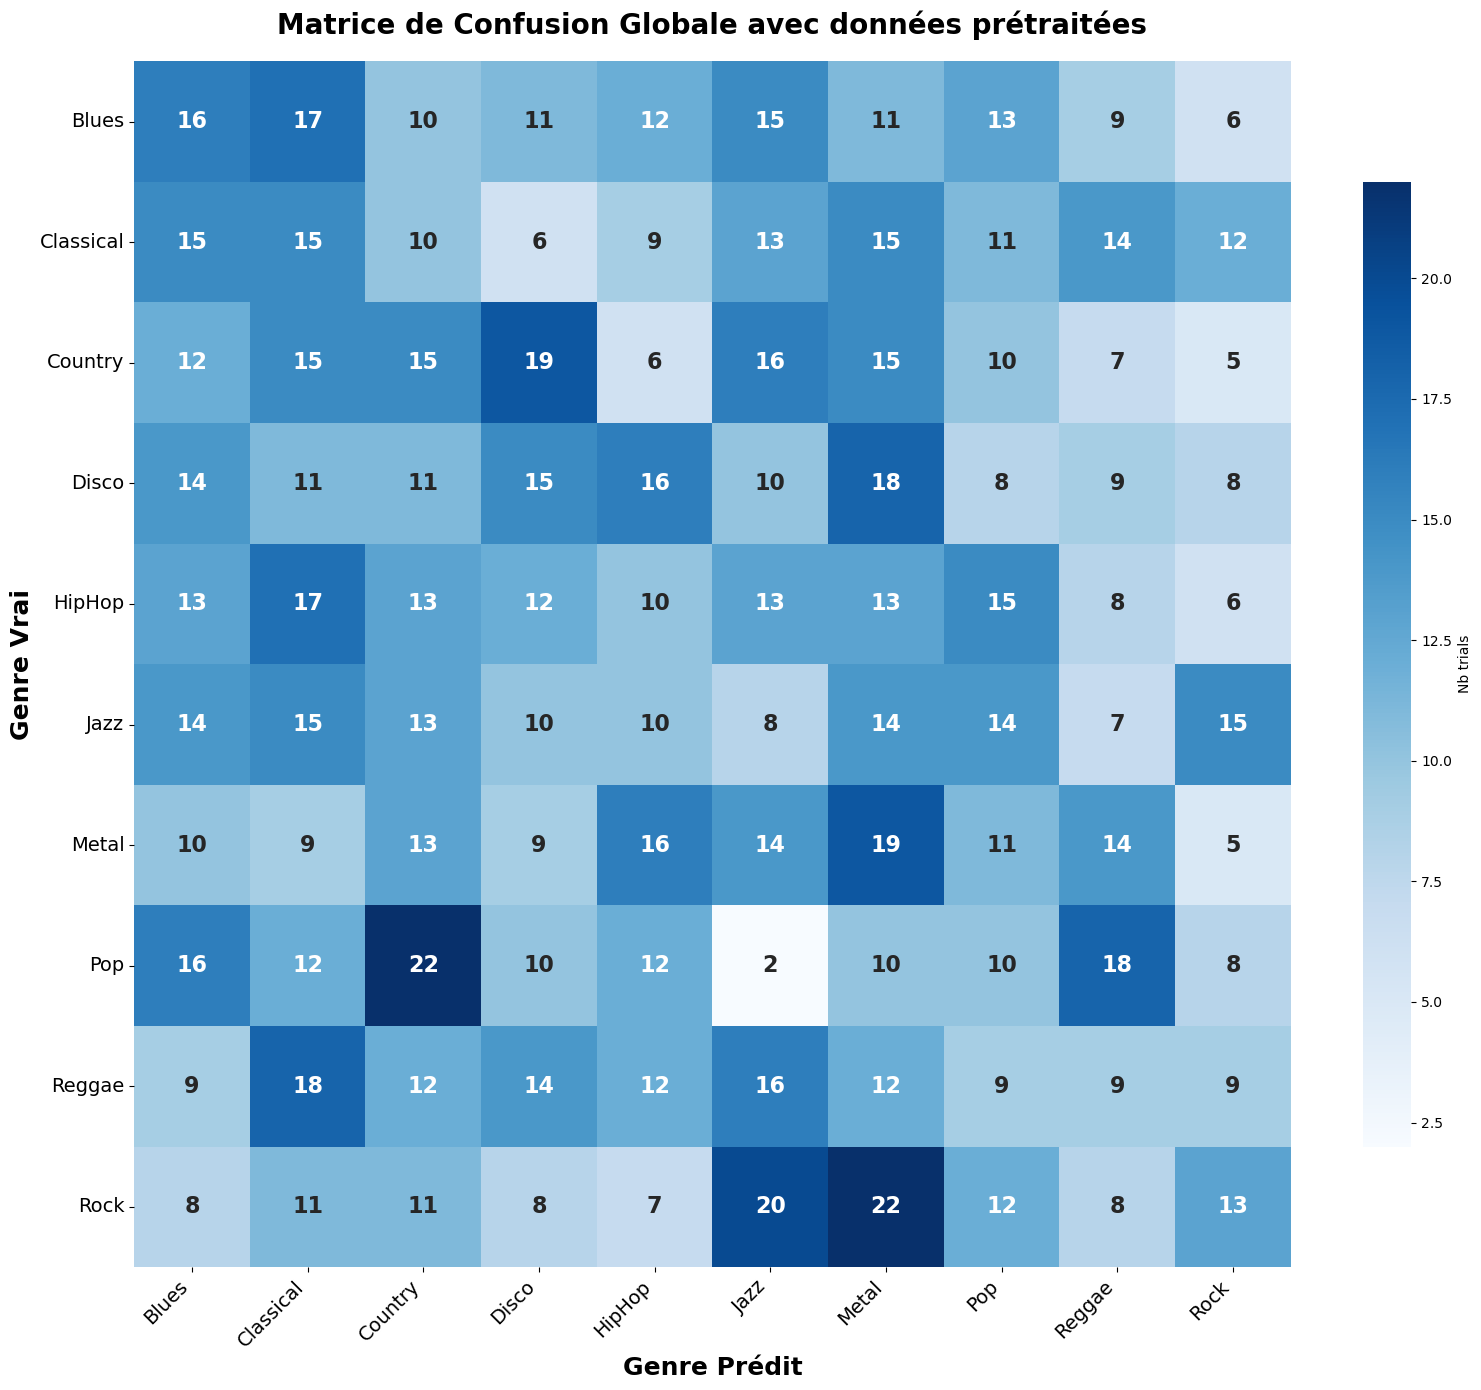

Acc globale: 10.8%


In [8]:
# Labels genres (GTZAN ds003720 confirmé [cite:37])
genres_gtzan = ['Blues', 'Classical', 'Country', 'Disco', 'HipHop', 
                'Jazz', 'Metal', 'Pop', 'Reggae', 'Rock']


# Matrice de confusion globale
cm_global = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(16, 14))  # GRAND
sns.heatmap(cm_global, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=genres_gtzan, 
            yticklabels=genres_gtzan,
            annot_kws={'size': 16, 'weight': 'bold'},  # TEXTE GROS + BOLD
            cbar_kws={'label': 'Nb trials', 'shrink': 0.8})
plt.title('Matrice de Confusion Globale avec données prétraitées', 
          fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Genre Prédit', fontsize=18, fontweight='bold')
plt.ylabel('Genre Vrai', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.savefig(output_dir/ 'CM_GLOBAL.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Acc globale: {accuracy_score(y_test_enc, y_pred):.1%}")

8. Résultats par sujet
On évalue maintenant les performances séparément pour chaque sujet afin d’observer la variabilité interindividuelle.

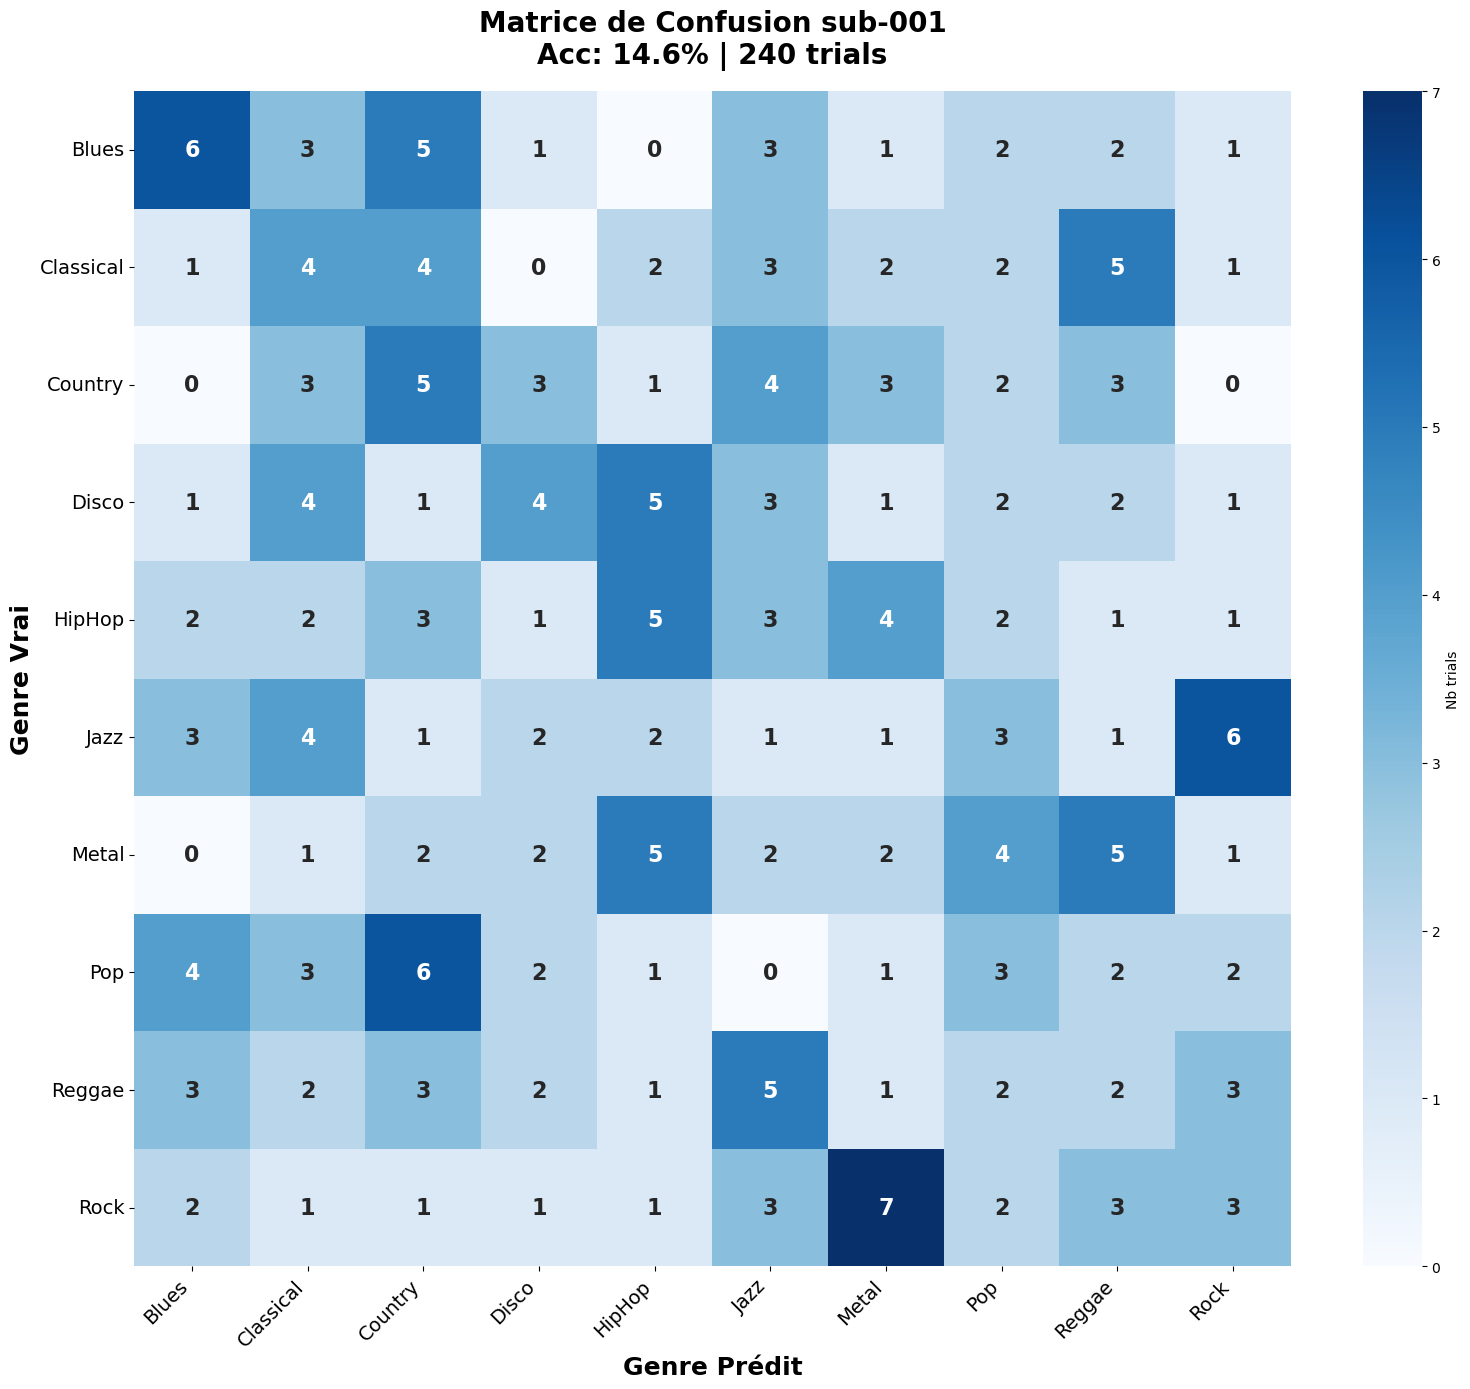

sub-001: Acc 14.6%


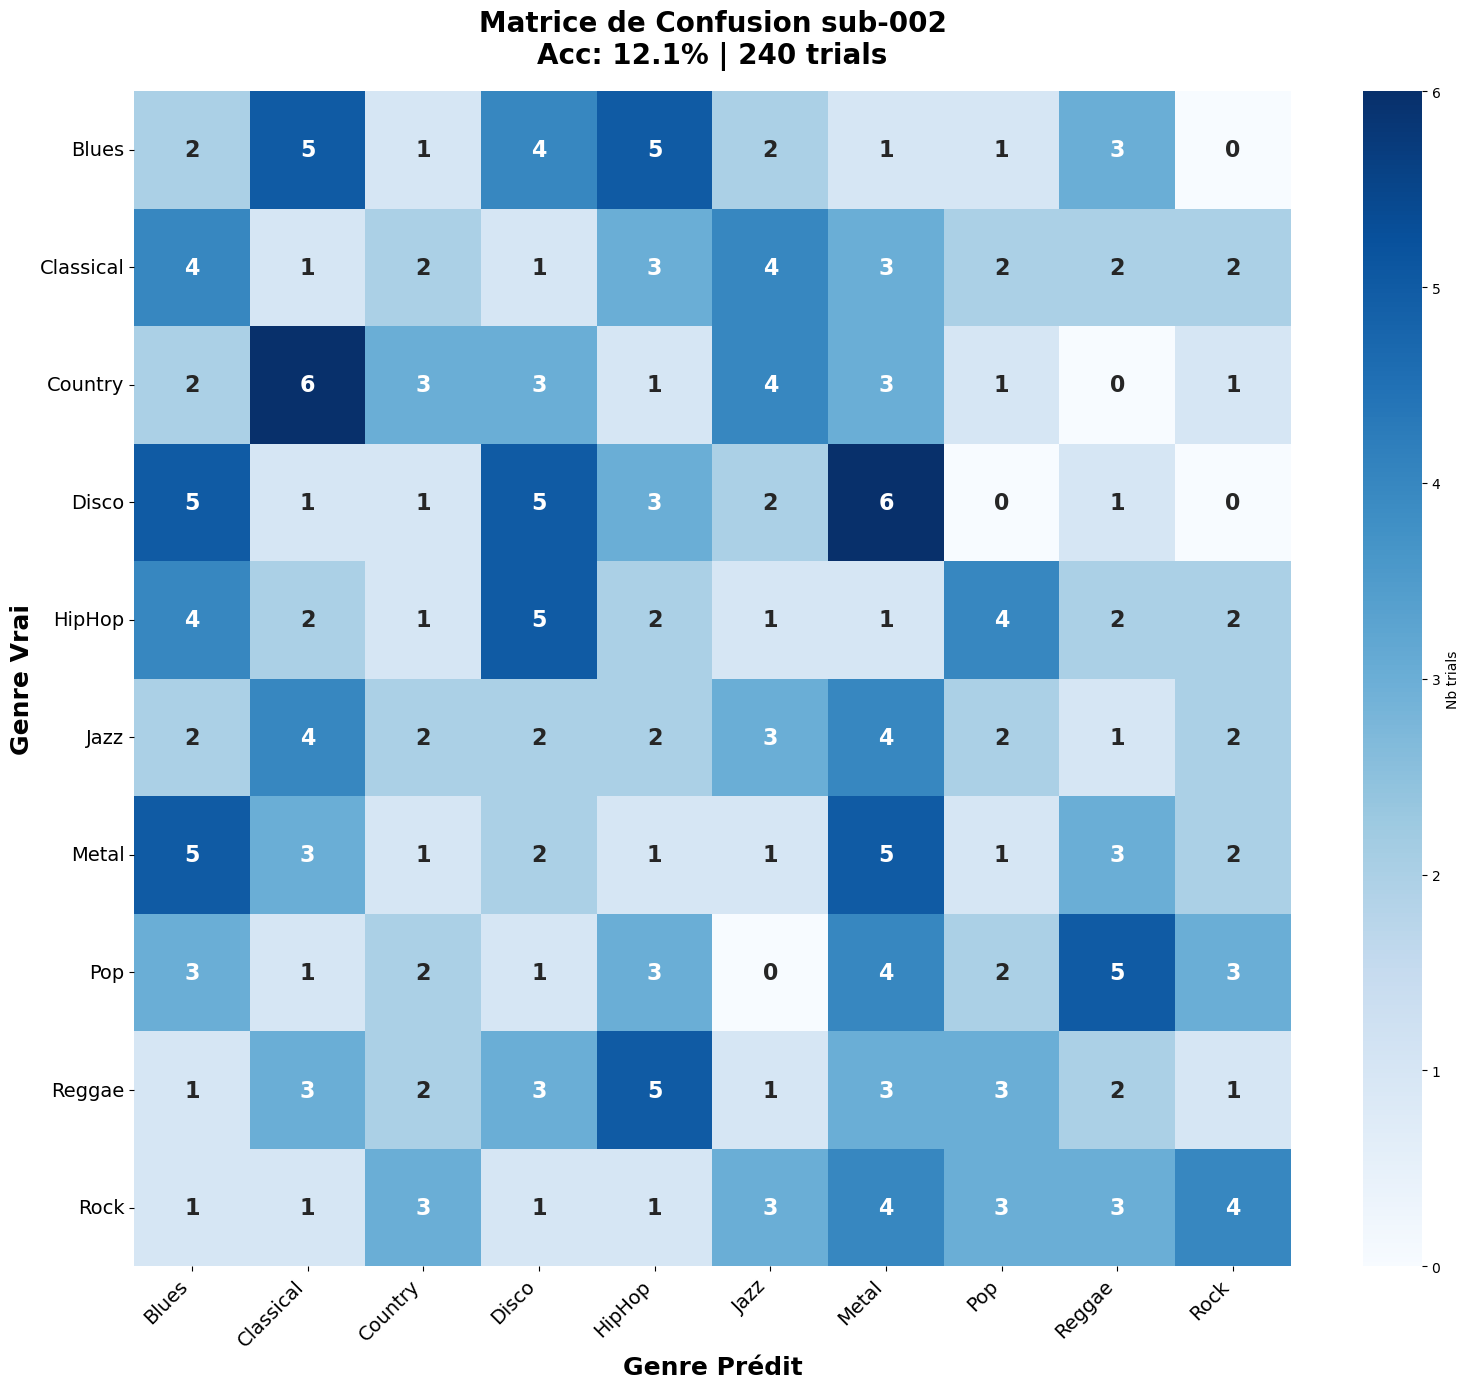

sub-002: Acc 12.1%


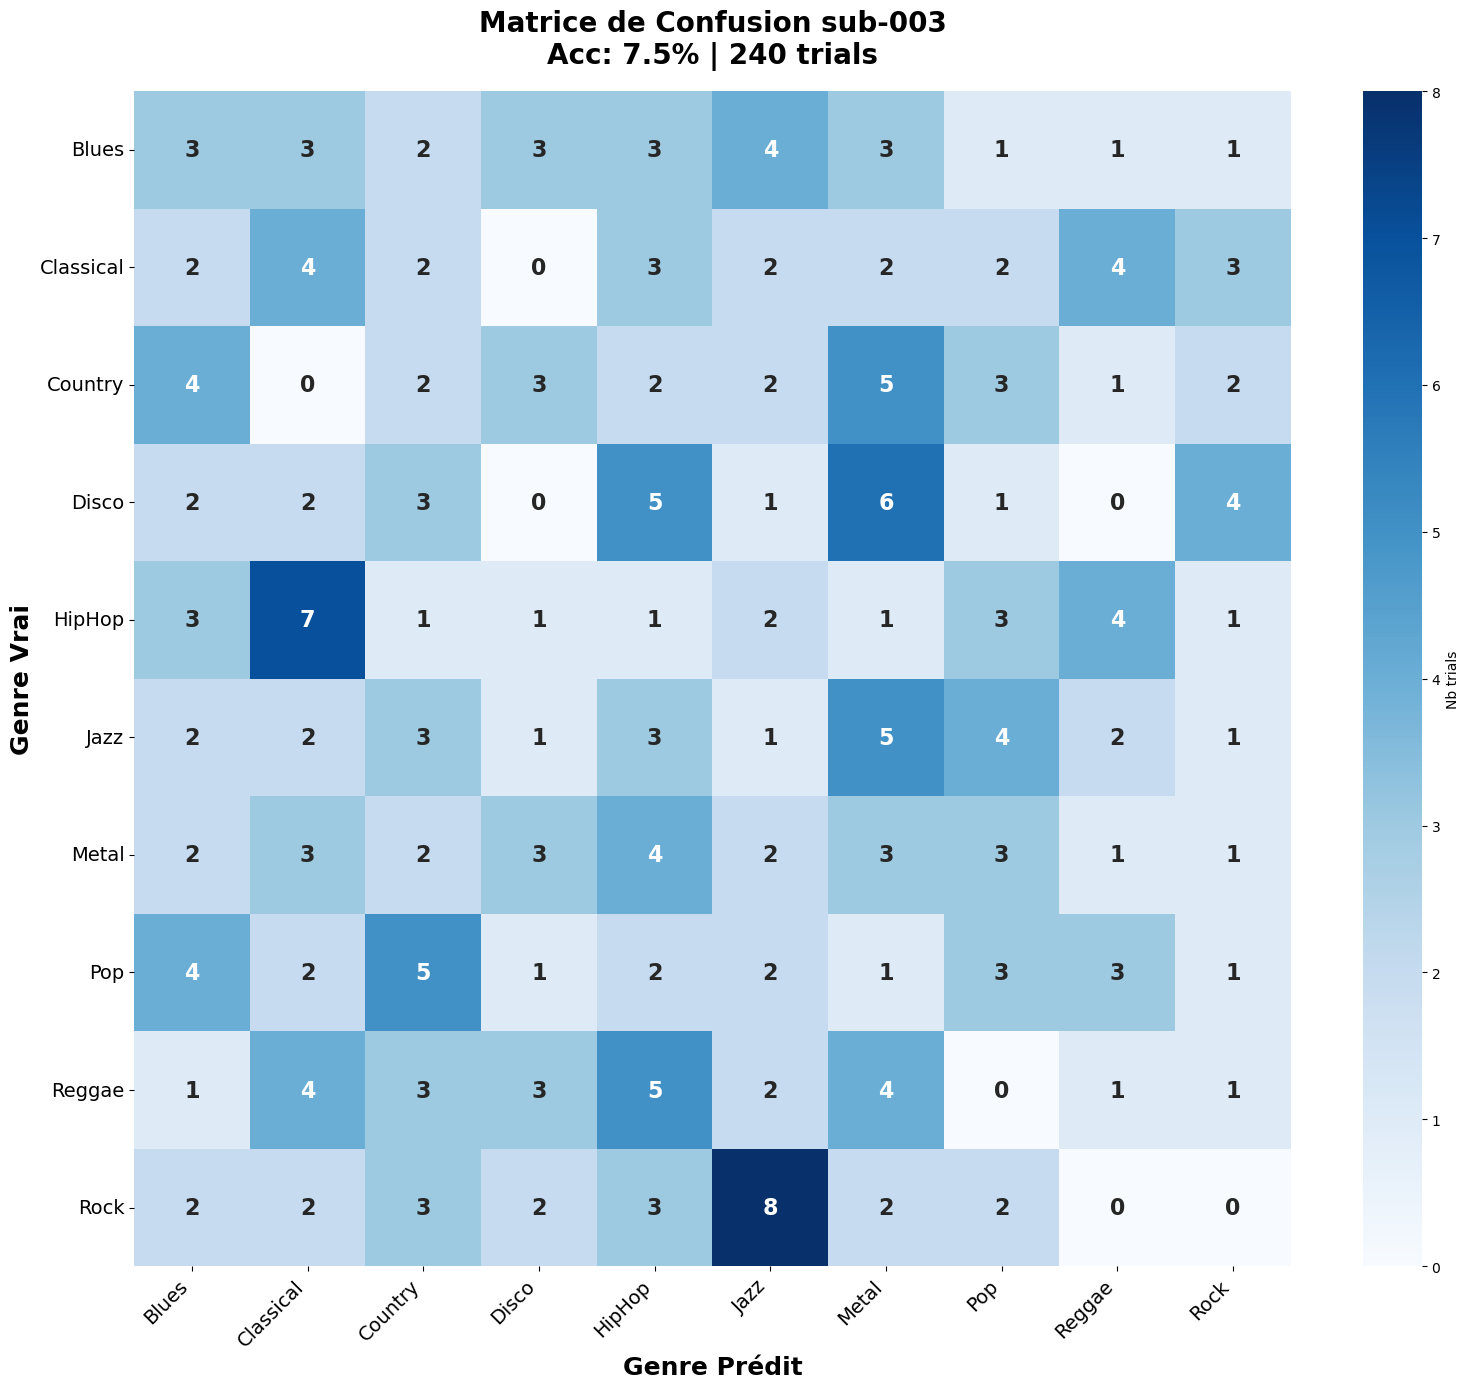

sub-003: Acc 7.5%


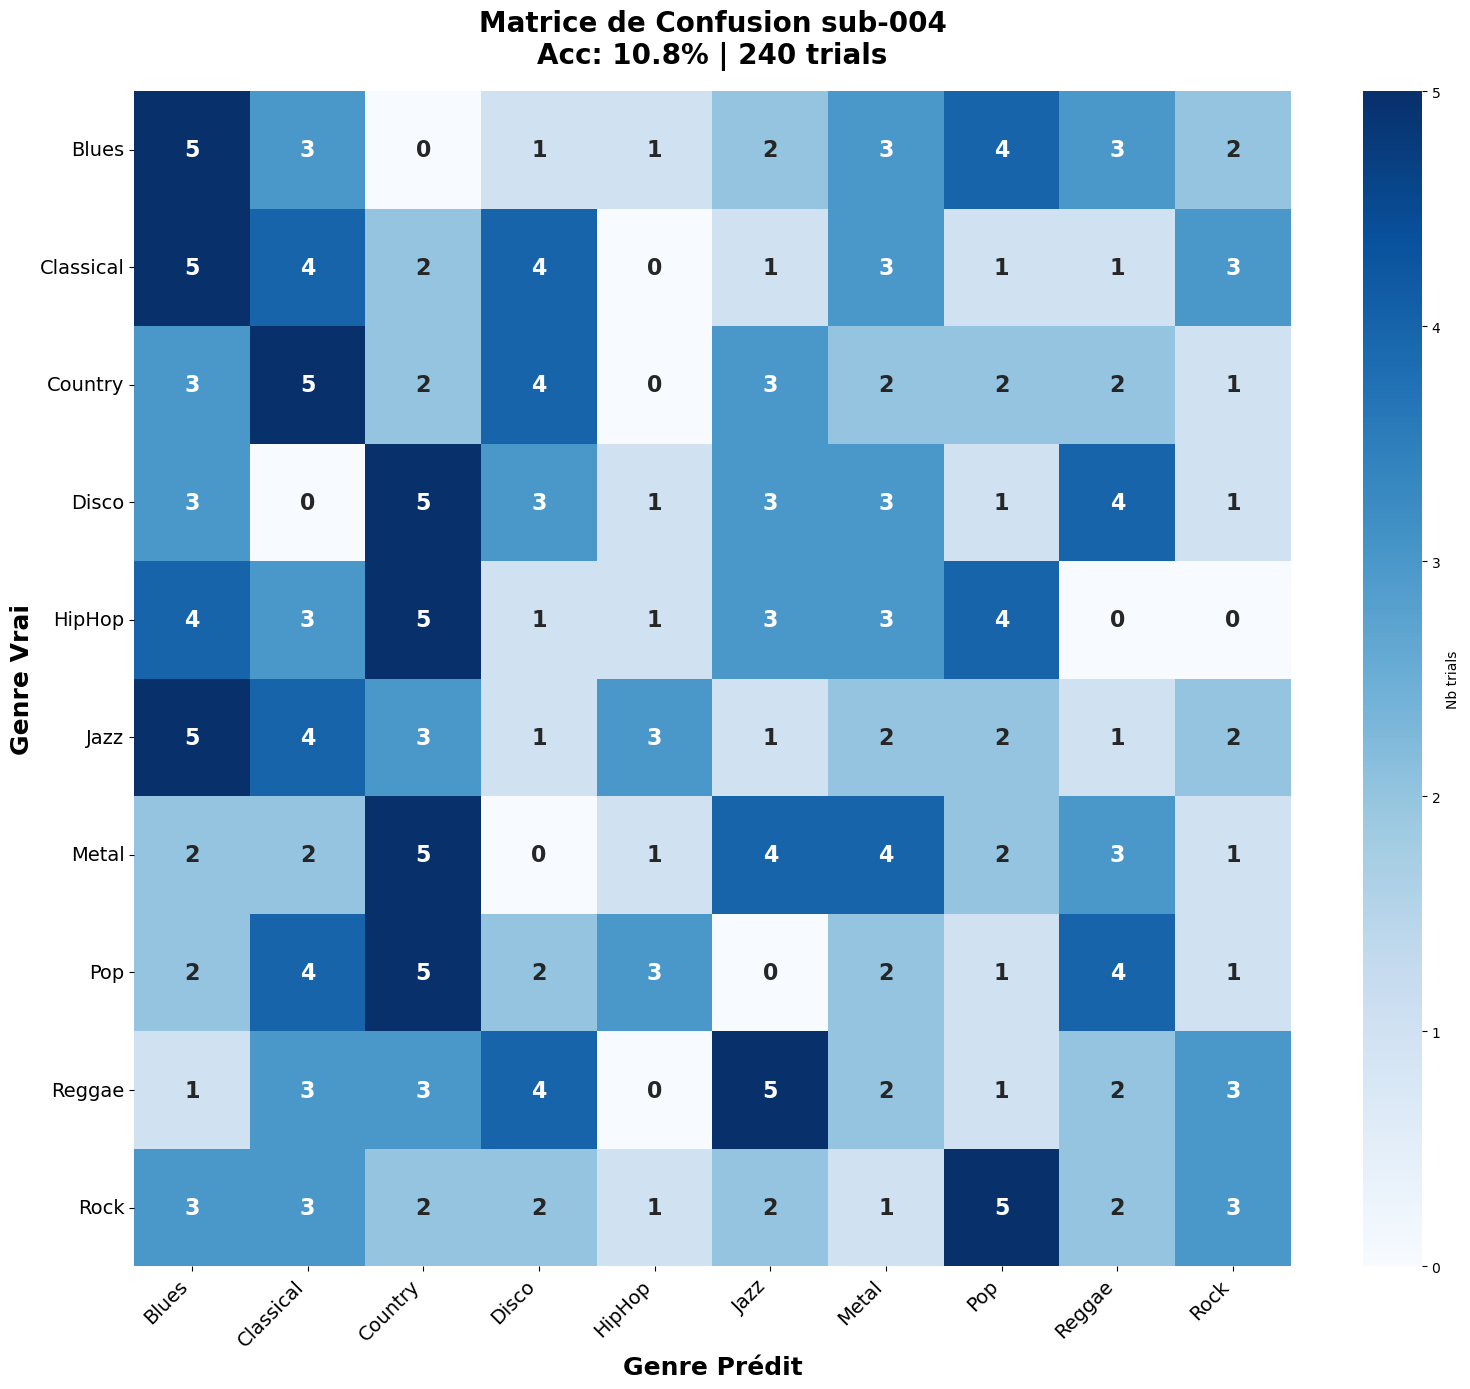

sub-004: Acc 10.8%


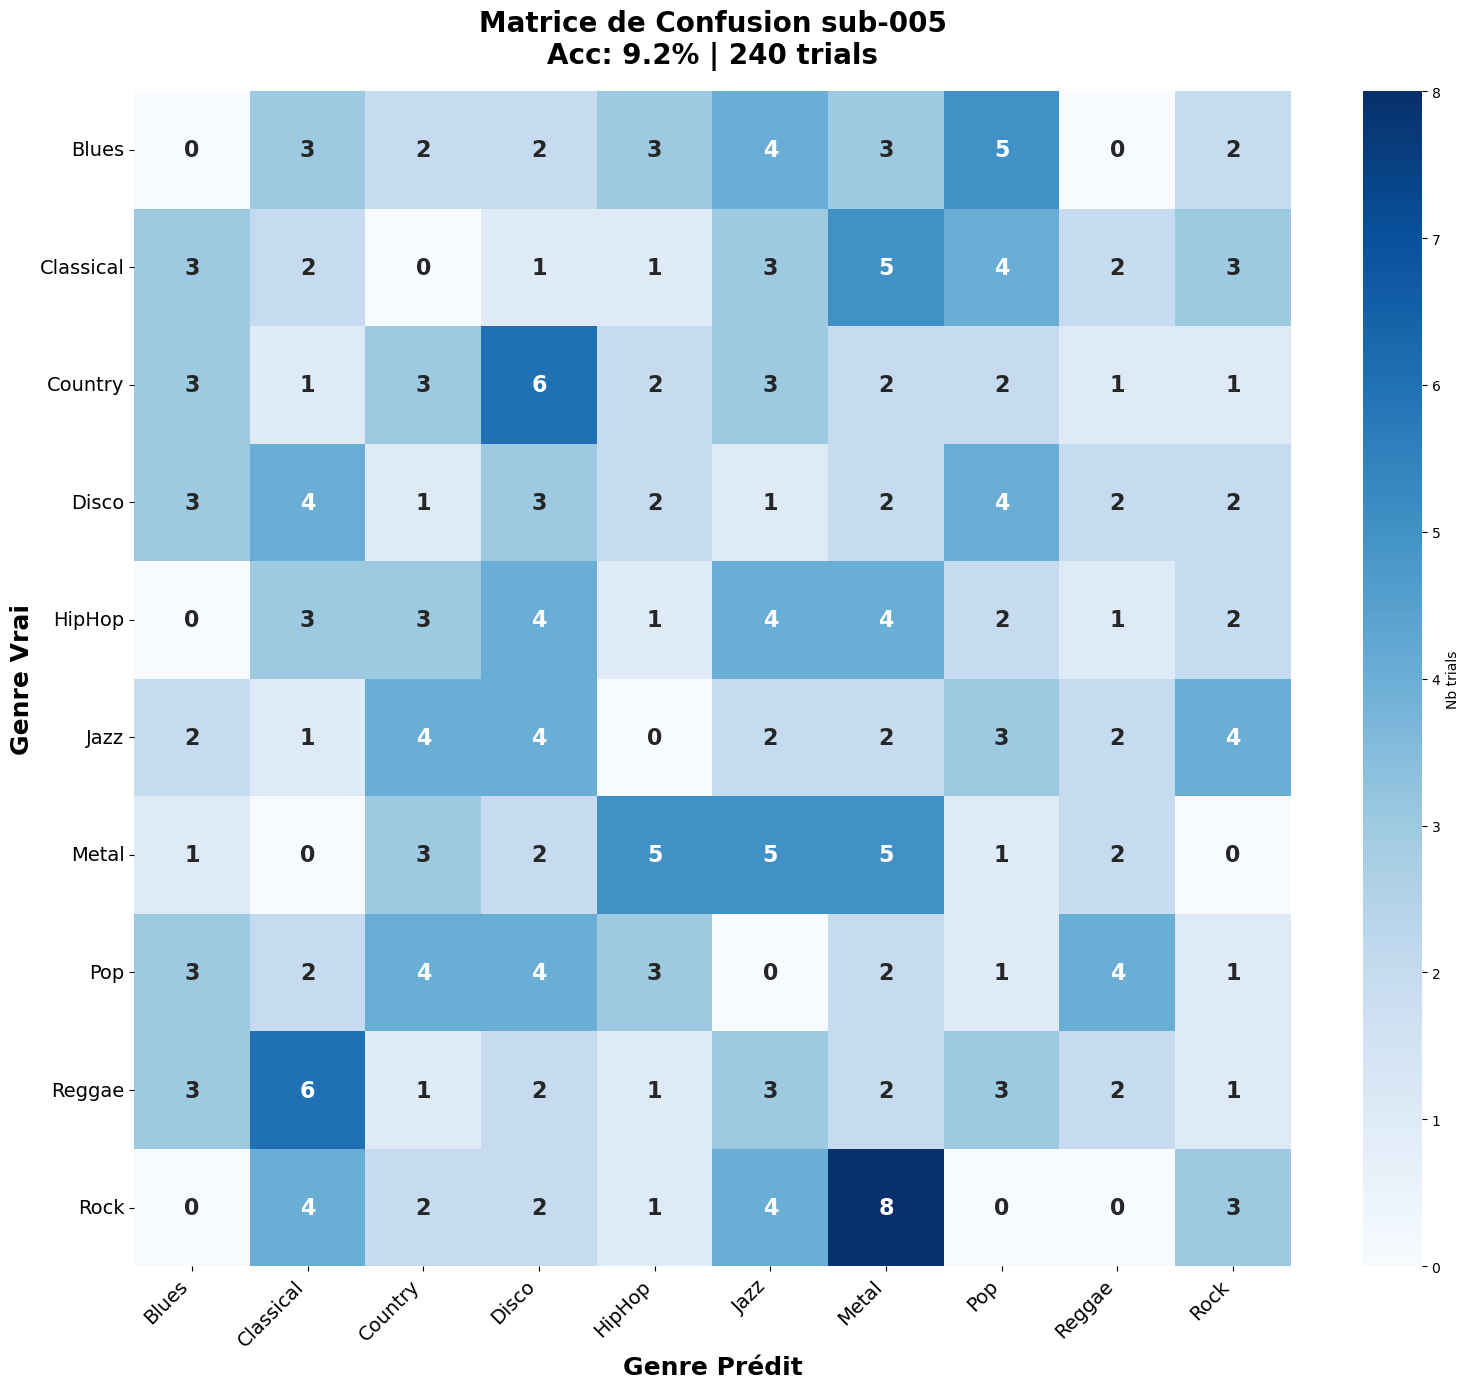

sub-005: Acc 9.2%


In [9]:
# Matrice de confusion par sujet
for subj in subjects:
    mask = subjects_test == subj
    if mask.sum() > 0:
        y_t_s, y_p_s = y_test_enc[mask], y_pred[mask]
        acc_s = accuracy_score(y_t_s, y_p_s)
        cm_s = confusion_matrix(y_t_s, y_p_s)
        
        plt.figure(figsize=(16, 14))
        sns.heatmap(cm_s, 
                    annot=True, 
                    fmt='d', 
                    cmap='Blues', 
                    xticklabels=genres_gtzan, 
                    yticklabels=genres_gtzan,
                    annot_kws={'size': 16, 'weight': 'bold'},
                    cbar_kws={'label': 'Nb trials'})
        plt.title(f'Matrice de Confusion {subj}\nAcc: {acc_s:.1%} | {len(y_t_s)} trials', 
                  fontsize=20, fontweight='bold', pad=20)
        plt.xlabel('Genre Prédit', fontsize=18, fontweight='bold')
        plt.ylabel('Genre Vrai', fontsize=18, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.yticks(rotation=0, fontsize=14)
        plt.tight_layout()
        plt.savefig(output_dir/f'CM_{subj}.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
        print(f"{subj}: Acc {acc_s:.1%}")

9. Dashboard final
Cette dernière section regroupe les résultats globaux et les performances par sujet dans une même figure pour faciliter la lecture.

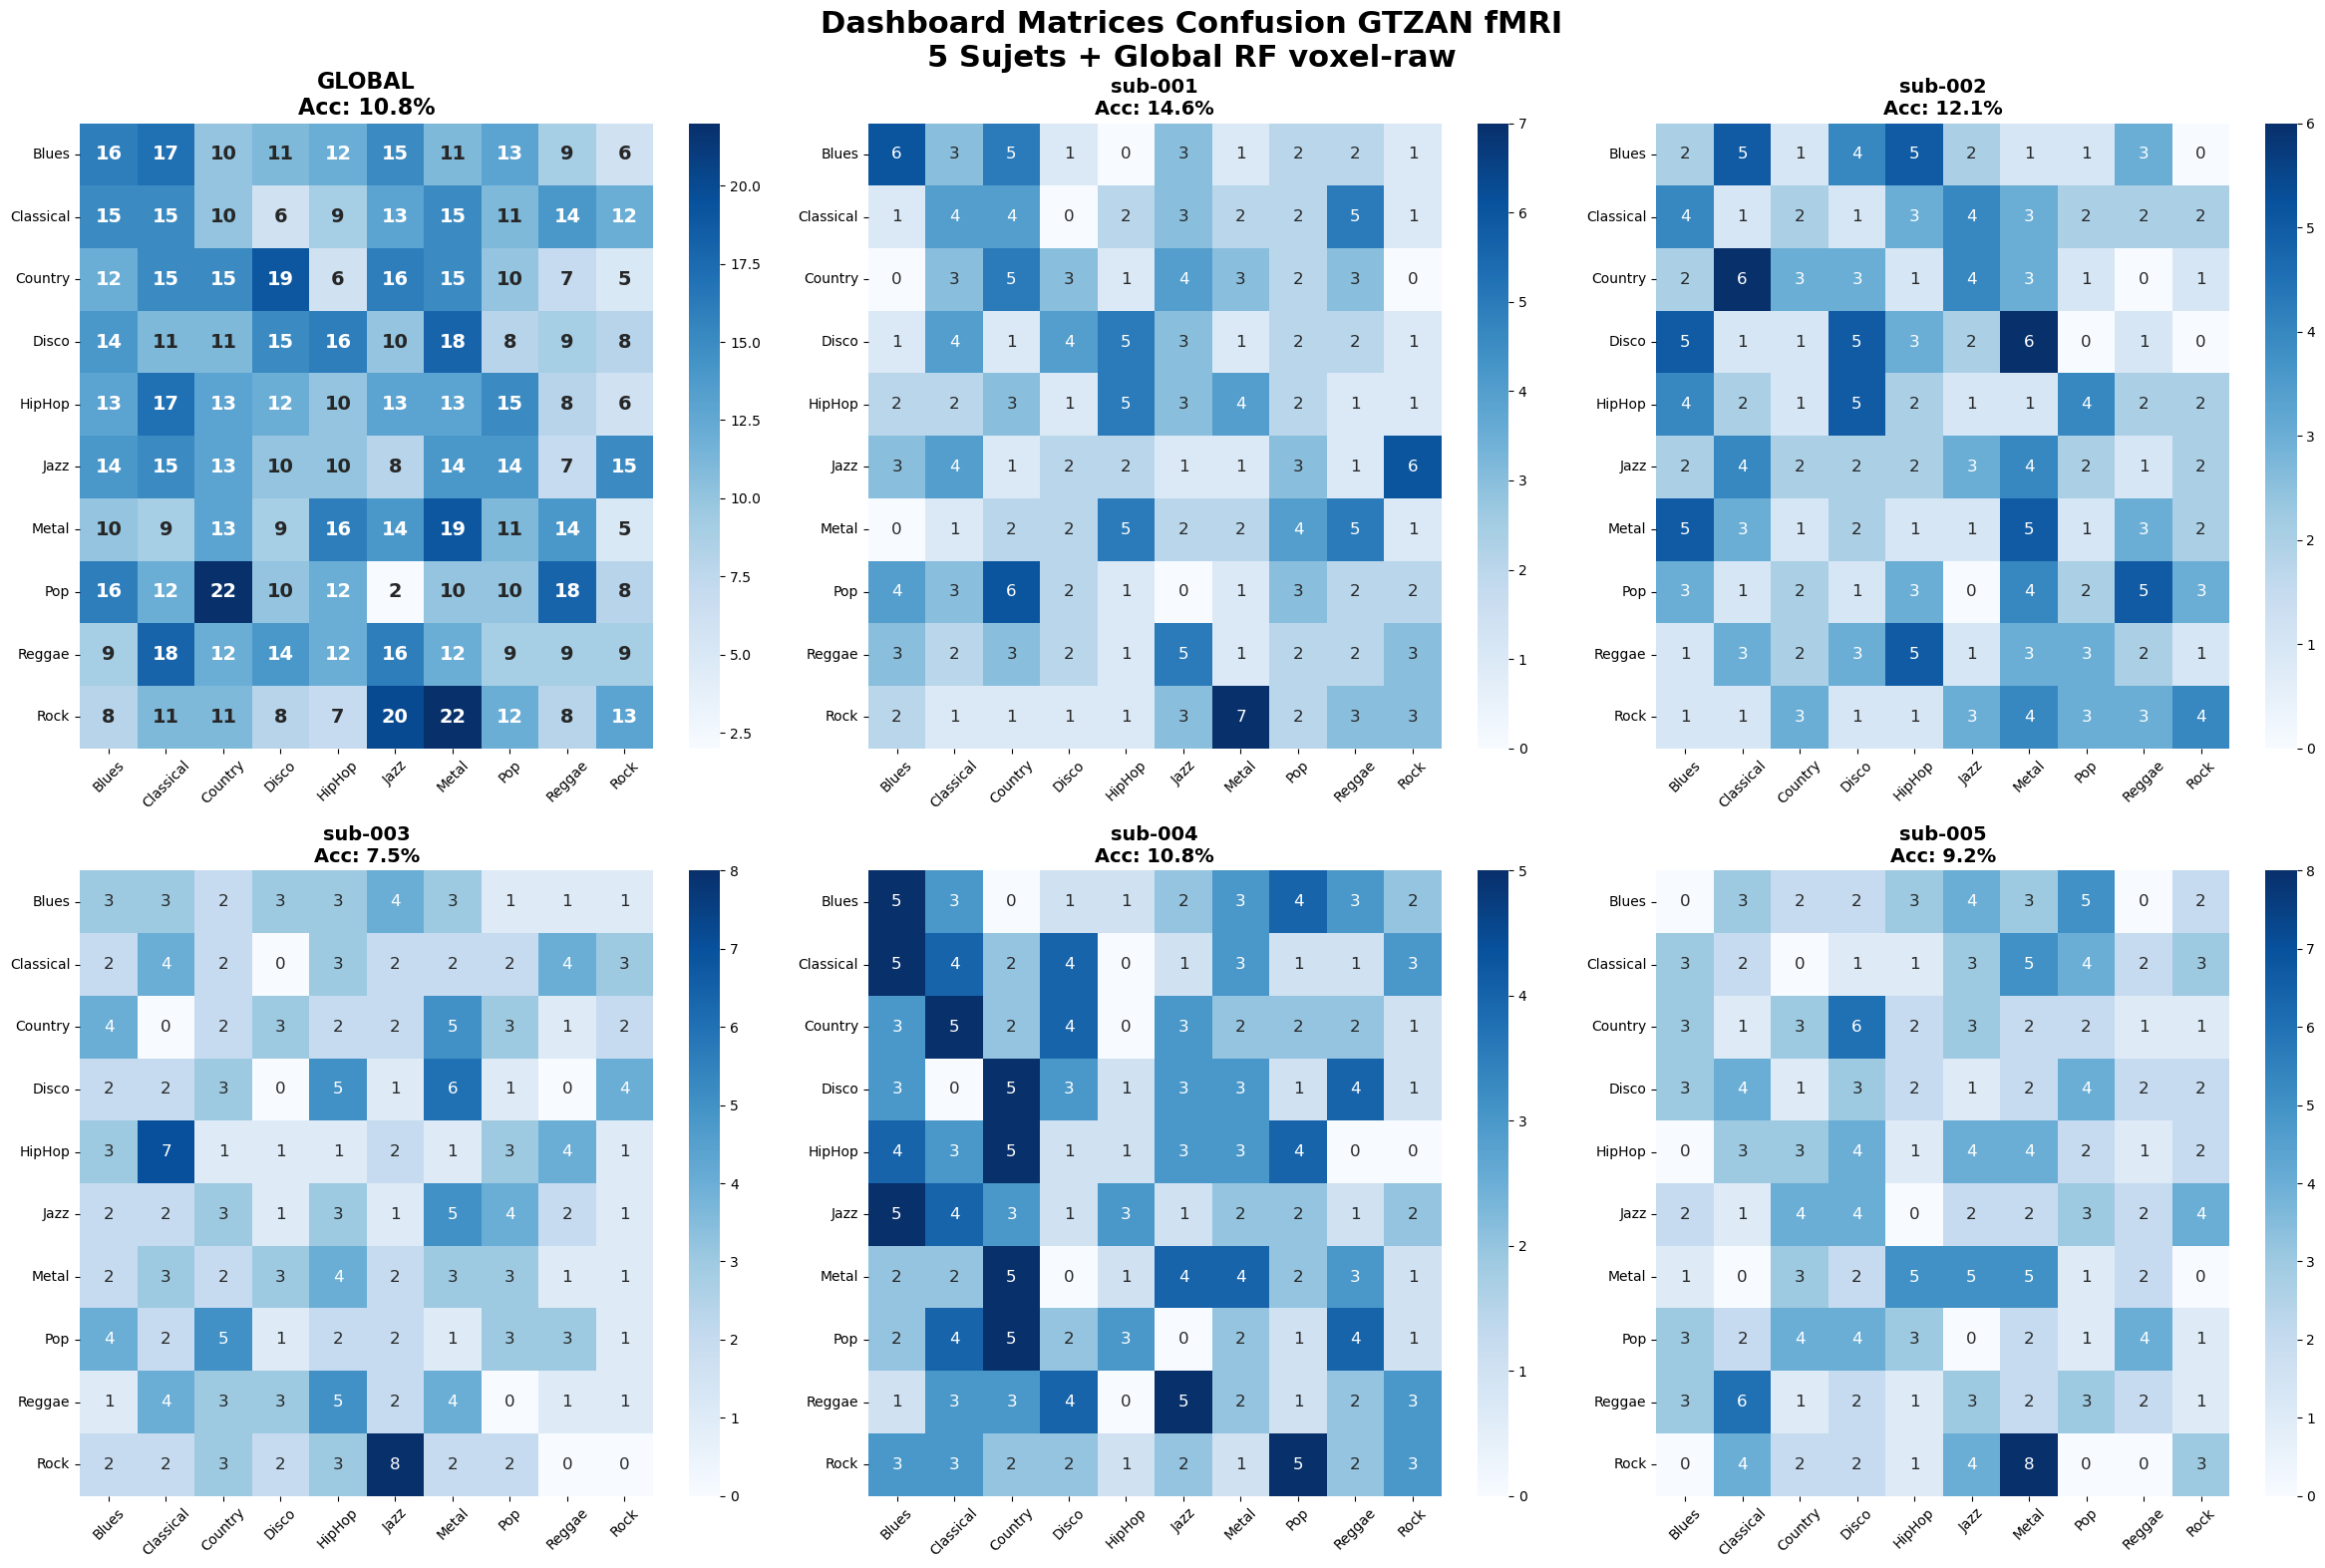

Images sauvegardées !


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
axes = axes.ravel()

# Global
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=genres_gtzan, yticklabels=genres_gtzan,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('GLOBAL\nAcc: {:.1%}'.format(acc_global), fontsize=16, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Sujets
for i, subj in enumerate(subjects):
    if i >= 5: 
        axes[i+1].axis('off')
        continue
    mask = subjects_test == subj
    if mask.sum() > 0:
        cm_s = confusion_matrix(y_test_enc[mask], y_pred[mask])
        sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues', ax=axes[i+1],
                    xticklabels=genres_gtzan, yticklabels=genres_gtzan,
                    annot_kws={'size': 12})
        axes[i+1].set_title(f'{subj}\nAcc: {accuracy_score(y_test_enc[mask], y_pred[mask]):.1%}', 
                           fontsize=14, fontweight='bold')
        axes[i+1].tick_params(axis='x', rotation=45)

plt.suptitle('Dashboard Matrices Confusion GTZAN fMRI\n5 Sujets + Global RF voxel-raw', 
             fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(output_dir/'DASHBOARD_CM_TOUS.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Images sauvegardées !")